# GRM Parameter Comparison: mirt vs PyMC

Compares item parameter estimates from:
- **mirt** (R) — `./results/mirt_params.csv`
- **PyMC** (Python) — `./results/pymc_params.csv`

Both are in the GRM threshold parameterisation:
- `a`: discrimination
- `b1` … `b8`: ordered threshold parameters ($b_{jk}$)

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

In [134]:
mirt  = pd.read_csv("./results/mirt_params.csv")
pymc  = pd.read_csv("./results/pymc_params.csv")

# Align on item column
mirt  = mirt.set_index("item").round(3)
pymc  = pymc.set_index("item").round(3)

items = mirt.index.tolist()
J = len(items)
b_cols = [c for c in mirt.columns if c.startswith("b")]
K_minus1 = len(b_cols)

print(f"Items: {J}   Thresholds per item: {K_minus1}")
print("\nmirt:")
display(mirt.head())
print("\nPyMC:")
display(pymc.head())

Items: 20   Thresholds per item: 4

mirt:


,a,b1,b2,b3,b4
item,,,,,
item_1,1.002,0.353,0.383,NaN,NaN
item_2,0.648,0.499,0.715,NaN,NaN
item_3,0.947,-1.742,-0.245,NaN,NaN
item_4,1.366,-2.065,0.073,NaN,NaN
item_5,1.029,0.066,1.117,NaN,NaN



PyMC:


,a,b1,b2,b3,b4
item,,,,,
item_1,0.980,0.359,0.394,NaN,NaN
item_2,0.642,0.501,0.729,NaN,NaN
item_3,0.935,-1.770,-0.243,NaN,NaN
item_4,1.350,-2.091,0.076,NaN,NaN
item_5,1.011,0.064,1.140,NaN,NaN


## Discrimination parameters ($a_j$)

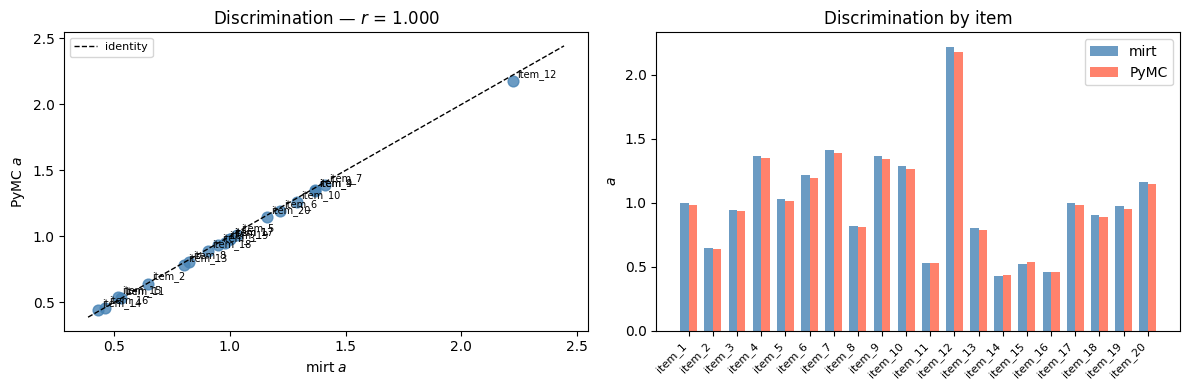

Pearson r = 0.9998, p = 9.9653e-33


In [135]:
a_mirt = mirt["a"].values
a_pymc = pymc["a"].values

r, pval = stats.pearsonr(a_mirt, a_pymc)
lo = min(a_mirt.min(), a_pymc.min()) * 0.9
hi = max(a_mirt.max(), a_pymc.max()) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
ax = axes[0]
ax.scatter(a_mirt, a_pymc, s=60, alpha=0.8, color="steelblue")
for i, item in enumerate(items):
    ax.annotate(item, (a_mirt[i], a_pymc[i]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
ax.set_xlabel("mirt $a$")
ax.set_ylabel("PyMC $a$")
ax.set_title(f"Discrimination — $r$ = {r:.3f}")
ax.legend(fontsize=8)

# Bar comparison
ax = axes[1]
x = np.arange(J)
w = 0.35
ax.bar(x - w/2, a_mirt, w, label="mirt",  color="steelblue", alpha=0.8)
ax.bar(x + w/2, a_pymc, w, label="PyMC", color="tomato",    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("$a$")
ax.set_title("Discrimination by item")
ax.legend()

plt.tight_layout()
plt.show()
print(f"Pearson r = {r:.4f}, p = {pval:.4e}")

## Threshold parameters ($b_{jk}$)

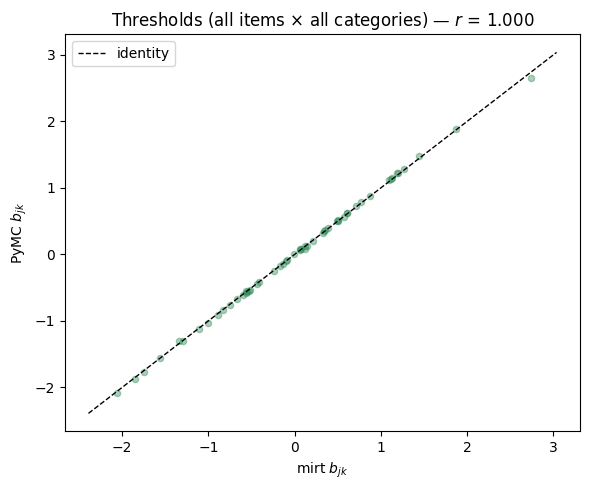

Pearson r = 0.9998, p = 2.0049e-91


In [136]:
b_mirt = pd.Series(mirt[b_cols].values.ravel()).dropna().values   # (J * (K-1),)
b_pymc = pd.Series(pymc[b_cols].values.ravel()).dropna().values   # (J * (K-1),)


r_b, pval_b = stats.pearsonr(b_mirt, b_pymc)
lo_b = min(b_mirt.min(), b_pymc.min()) - 0.3
hi_b = max(b_mirt.max(), b_pymc.max()) + 0.3

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(b_mirt, b_pymc, s=20, alpha=0.4, color="seagreen")
ax.plot([lo_b, hi_b], [lo_b, hi_b], "k--", lw=1, label="identity")
ax.set_xlabel("mirt $b_{jk}$")
ax.set_ylabel("PyMC $b_{jk}$")
ax.set_title(f"Thresholds (all items × all categories) — $r$ = {r_b:.3f}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Pearson r = {r_b:.4f}, p = {pval_b:.4e}")

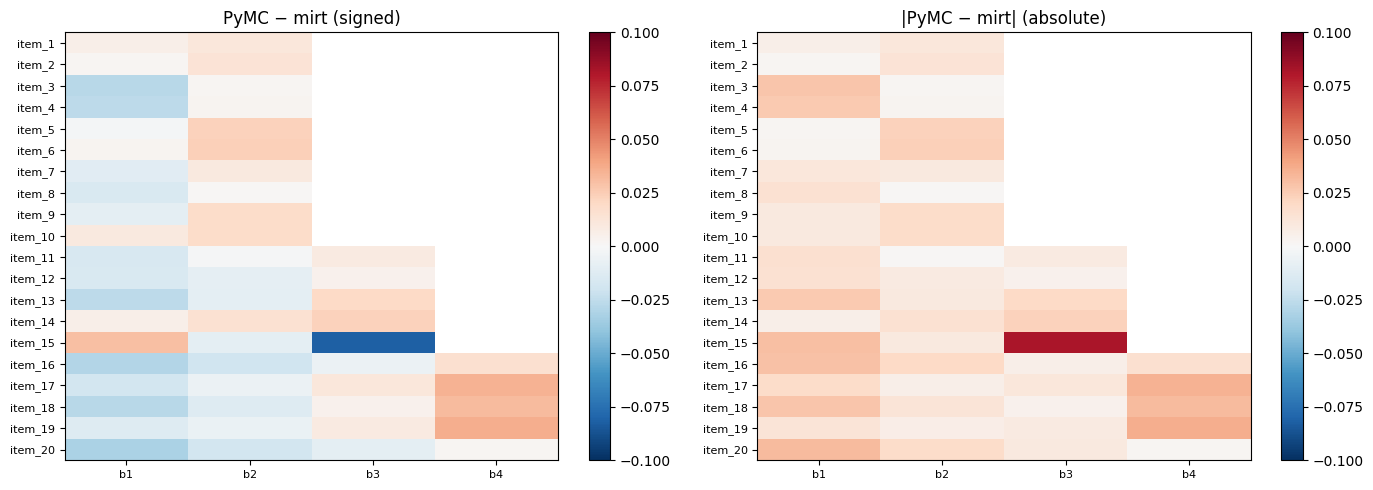

In [137]:
diff_b = pymc[b_cols].values - mirt[b_cols].values  # (J, K-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vmax = np.abs(diff_b).max()

for ax, data, title in zip(
    axes,
    [diff_b, np.abs(diff_b)],
    ["PyMC − mirt (signed)", "|PyMC − mirt| (absolute)"],
):
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(J))
    ax.set_yticklabels(items, fontsize=8)
    ax.set_xticks(range(K_minus1))
    ax.set_xticklabels([f"b{k+1}" for k in range(K_minus1)], fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Item parameters ($a_j, b_{jk}$)

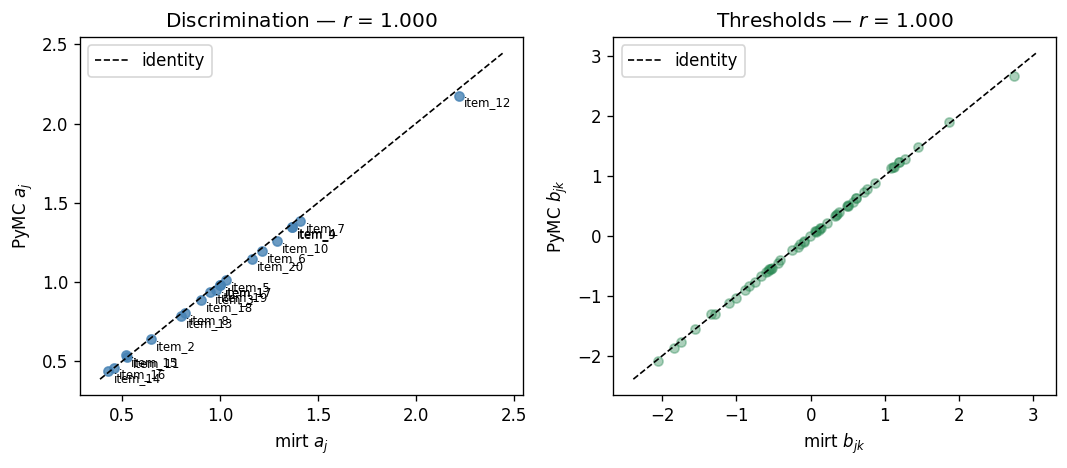

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=120)

# a
a_mirt = mirt["a"].values
a_pymc = pymc["a"].values

r, pval = stats.pearsonr(a_mirt, a_pymc)
lo = min(a_mirt.min(), a_pymc.min()) * 0.9
hi = max(a_mirt.max(), a_pymc.max()) * 1.1

ax = axes[0]
ax.scatter(a_mirt, a_pymc, s=30, alpha=0.8, color="steelblue")
for i, item in enumerate(items):
    ax.annotate(item, (a_mirt[i], a_pymc[i] - 0.1), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
ax.set_xlabel("mirt $a_j$")
ax.set_ylabel("PyMC $a_j$")
ax.set_title(f"Discrimination — $r$ = {r:.3f}")
ax.legend(fontsize=10)

# b
ax = axes[1]
b_mirt = pd.Series(mirt[b_cols].values.ravel()).dropna().values   # (J * (K-1),)
b_pymc = pd.Series(pymc[b_cols].values.ravel()).dropna().values   # (J * (K-1),)

r_b, pval_b = stats.pearsonr(b_mirt, b_pymc)
lo_b = min(b_mirt.min(), b_pymc.min()) - 0.3
hi_b = max(b_mirt.max(), b_pymc.max()) + 0.3

ax.scatter(b_mirt, b_pymc, s=30, alpha=0.4, color="seagreen")
ax.plot([lo_b, hi_b], [lo_b, hi_b], "k--", lw=1, label="identity")
ax.set_xlabel("mirt $b_{jk}$")
ax.set_ylabel("PyMC $b_{jk}$")
ax.set_title(f"Thresholds — $r$ = {r_b:.3f}")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig("./results/item_params.png")

## Latent trait ($\theta_i$)

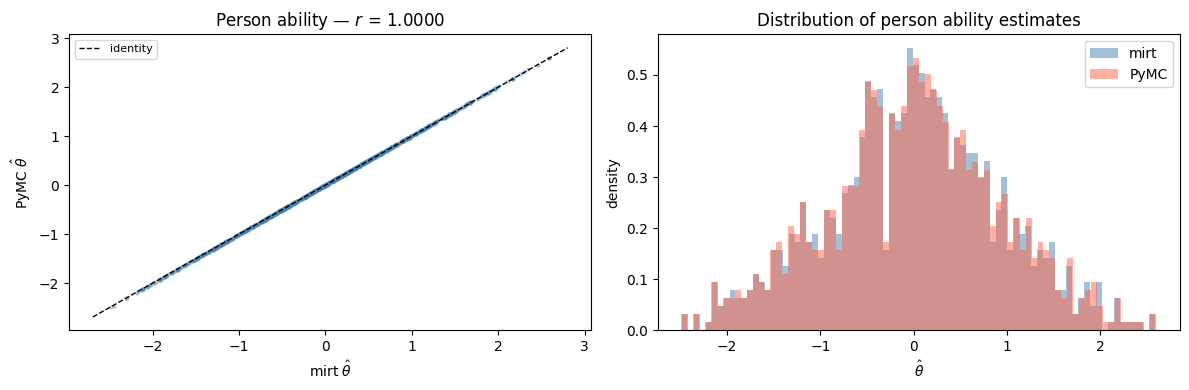

Pearson r = 1.0000, p = 0.0000e+00
MAE = 0.0055  RMSE = 0.0069  bias = -0.0001


In [139]:
mirt_theta = pd.read_csv("./results/mirt_theta.csv")["theta"].values
pymc_theta = pd.read_csv("./results/pymc_theta.csv")["theta"].values

r_t, pval_t = stats.pearsonr(mirt_theta, pymc_theta)
lo_t = min(mirt_theta.min(), pymc_theta.min()) - 0.2
hi_t = max(mirt_theta.max(), pymc_theta.max()) + 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
ax = axes[0]
ax.scatter(mirt_theta, pymc_theta, s=5, alpha=0.3, color="steelblue", rasterized=True)
ax.plot([lo_t, hi_t], [lo_t, hi_t], "k--", lw=1, label="identity")
ax.set_xlabel(r"mirt $\hat{\theta}$")
ax.set_ylabel(r"PyMC $\hat{\theta}$")
ax.set_title(rf"Person ability — $r$ = {r_t:.4f}")
ax.legend(fontsize=8)

# Density overlay
ax = axes[1]
for vals, label, color in [(mirt_theta, "mirt", "steelblue"), (pymc_theta, "PyMC", "tomato")]:
    ax.hist(vals, bins=80, density=True, alpha=0.5, color=color, label=label)
ax.set_xlabel(r"$\hat{\theta}$")
ax.set_ylabel("density")
ax.set_title("Distribution of person ability estimates")
ax.legend()

plt.tight_layout()
plt.show()

mae_t  = np.mean(np.abs(pymc_theta - mirt_theta))
rmse_t = np.sqrt(np.mean((pymc_theta - mirt_theta) ** 2))
bias_t = np.mean(pymc_theta - mirt_theta)
print(f"Pearson r = {r_t:.4f}, p = {pval_t:.4e}")
print(f"MAE = {mae_t:.4f}  RMSE = {rmse_t:.4f}  bias = {bias_t:.4f}")

## Summary statistics

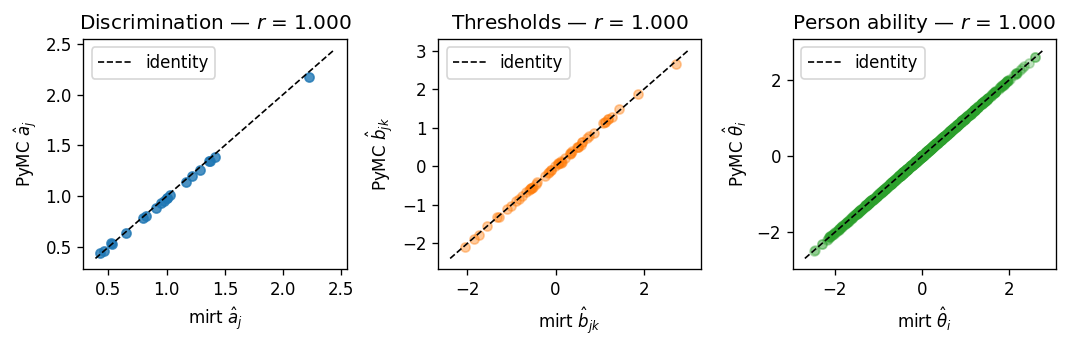

In [140]:
fig, axes = plt.subplots(ncols=3, figsize=(9, 3), dpi=120)

# ---------------------------------
# a
# ---------------------------------
a_mirt = mirt["a"].values
a_pymc = pymc["a"].values

r, pval = stats.pearsonr(a_mirt, a_pymc)
lo = min(a_mirt.min(), a_pymc.min()) * 0.9
hi = max(a_mirt.max(), a_pymc.max()) * 1.1

ax = axes[0]
ax.scatter(a_mirt, a_pymc, s=30, alpha=0.8, color="tab:blue")
# for i, item in enumerate(items):
#     ax.annotate(item, (a_mirt[i], a_pymc[i] - 0.1), fontsize=7,
#                 xytext=(3, 3), textcoords="offset points")
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
ax.set_xlabel(r"mirt $\hat{a}_j$")
ax.set_ylabel(r"PyMC $\hat{a}_j$")
ax.set_title(f"Discrimination — $r$ = {r:.3f}")
ax.legend(fontsize=10)

# ---------------------------------
# b
# ---------------------------------
ax = axes[1]
b_mirt = pd.Series(mirt[b_cols].values.ravel()).dropna().values   # (J * (K-1),)
b_pymc = pd.Series(pymc[b_cols].values.ravel()).dropna().values   # (J * (K-1),)

r_b, pval_b = stats.pearsonr(b_mirt, b_pymc)
lo_b = min(b_mirt.min(), b_pymc.min()) - 0.3
hi_b = max(b_mirt.max(), b_pymc.max()) + 0.3

ax.scatter(b_mirt, b_pymc, s=30, alpha=0.4, color="tab:orange")
ax.plot([lo_b, hi_b], [lo_b, hi_b], "k--", lw=1, label="identity")
ax.set_xlabel(r"mirt $\hat{b}_{jk}$")
ax.set_ylabel(r"PyMC $\hat{b}_{jk}$")
ax.set_title(f"Thresholds — $r$ = {r_b:.3f}")
ax.legend(fontsize=10)


# ---------------------------------
# theta
# ---------------------------------
mirt_theta = pd.read_csv("./results/mirt_theta.csv")["theta"].values
pymc_theta = pd.read_csv("./results/pymc_theta.csv")["theta"].values

r_t, pval_t = stats.pearsonr(mirt_theta, pymc_theta)
lo_t = min(mirt_theta.min(), pymc_theta.min()) - 0.2
hi_t = max(mirt_theta.max(), pymc_theta.max()) + 0.2

ax = axes[2]
ax.scatter(mirt_theta, pymc_theta, s=30, alpha=0.3, color="tab:green", rasterized=True)
ax.plot([lo_t, hi_t], [lo_t, hi_t], "k--", lw=1, label="identity")
ax.set_xlabel(r"mirt $\hat{\theta}_i$")
ax.set_ylabel(r"PyMC $\hat{\theta}_i$")
ax.set_title(rf"Person ability — $r$ = {r_t:.3f}")
ax.legend(fontsize=10)


plt.tight_layout()
plt.show()
fig.savefig("./results/item_params.png")

In [142]:
def r(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    return stats.pearsonr(x, y)[0]

def mae(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    return np.mean(np.abs(x - y))

def rmse(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    return np.sqrt(np.mean((x - y) ** 2))

item_params_summary = pd.DataFrame({
    "param":  ["a"] + b_cols,
    "r":      [r(pymc[p], mirt[p]) for p in ["a"] + b_cols],
    "MAE":    [mae(pymc[p], mirt[p]) for p in ["a"] + b_cols],
    "RMSE":   [rmse(pymc[p], mirt[p]) for p in ["a"] + b_cols],
    "bias":   [np.mean(pymc[p] - mirt[p]) for p in ["a"] + b_cols],
}).round(3)

theta_summary = pd.DataFrame({
    "param":  ["theta"],
    "r":      r(mirt_theta, pymc_theta),
    "MAE":    mae(pymc_theta, mirt_theta),
    "RMSE":   rmse(pymc_theta, mirt_theta),
    "bias":   np.mean(pymc_theta - mirt_theta),
}).round(3)


stats = pd.concat([item_params_summary, theta_summary], ignore_index=True)
stats

,param,r,MAE,RMSE,bias
0,a,1.0,0.018,0.021,-0.015
1,b1,1.0,0.016,0.019,-0.011
2,b2,1.0,0.012,0.014,0.002
3,b3,1.0,0.018,0.028,-0.002
4,b4,1.0,0.024,0.028,0.024
5,theta,1.0,0.006,0.007,-0.000


In [147]:
print(stats.to_markdown(index=False))

| param   |   r |   MAE |   RMSE |   bias |
|:--------|----:|------:|-------:|-------:|
| a       |   1 | 0.018 |  0.021 | -0.015 |
| b1      |   1 | 0.016 |  0.019 | -0.011 |
| b2      |   1 | 0.012 |  0.014 |  0.002 |
| b3      |   1 | 0.018 |  0.028 | -0.002 |
| b4      |   1 | 0.024 |  0.028 |  0.024 |
| theta   |   1 | 0.006 |  0.007 | -0     |
